### Human in the Loop

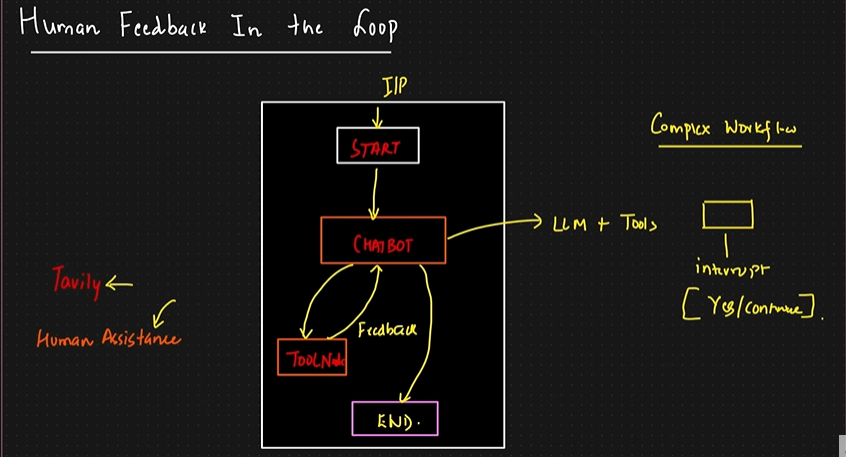

In [6]:
import os
from langchain.chat_models import init_chat_model
llm=init_chat_model("google_genai:gemini-3.5-flash-lite")
llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.0', 'langchain-google-genai': '4.4.0'}}, profile={'name': 'Gemini 3.5 Flash Lite', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'minimal'}, google_api_key=SecretStr('**********'), model='gemini-3.5-flash-lite', temperature=None, client=<google.genai.client.Client object at 0x000001B8E88A5E80>, default_metadata=(), model_kwar

In [7]:
from email import message
from groq.types.audio import transcription_create_params
from groq.types.audio import transcription_create_params
from groq.types.audio import transcription_create_params
from groq.types.audio import transcription_create_params
from groq.types.audio import transcription_create_params
from groq.types.audio import transcription_create_params
from groq.types.audio import transcription_create_params
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph. types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request Assistance from a human"""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")




In [8]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

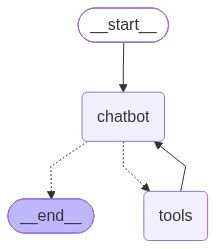

In [9]:
from IPython.display import Image, display

try:
    display(Image.get_graph().draw_mermaid_png())
except Exception:
    # This requires some extra dependencies and is optional
    pass

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
        config,
        stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()


================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================

[]
Tool Calls:
  human_assistance (call_14431)
 Call ID: call_14431
  Args:
    query: User needs expert guidance and assistance for building an AI agent.
================================== Ai Message ==================================

[]
Tool Calls:
  human_assistance (call_14431)
 Call ID: call_14431
  Args:
    query: User needs expert guidance and assistance for building an AI agent.


In [12]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command= Command(resume={"data": human_response})

events = graph. stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================

[]
Tool Calls:
  human_assistance (call_14431)
 Call ID: call_14431
  Args:
    query: User needs expert guidance and assistance for building an AI agent.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Our team of experts has responded! They recommend checking out **LangGraph** to build your agent, noting that it is much more reliable and extensible than simple autonomous agents. \n\nWould you like to dive deeper into how LangGraph works, or do you have specific requirements in mind for your AI agent (like its purpose, tech stack, or architecture)?', 'extras': {'signature': 'El4KX